# GRN inference with Arboreto/GRNBoost2



In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from arboreto.algo import grnboost2

In [3]:
# Load the preprocessed h5ad file
adata = sc.read_h5ad("data/filtered_counts.h5ad")
print(f"Dataset shape: {adata.shape}")

Dataset shape: (14637, 17056)


In [21]:
!wget -nc https://resources.aertslab.org/cistarget/tf_lists/allTFs_mm.txt
!mv ./allTFs_mm.txt ./data

File ‘allTFs_mm.txt’ already there; not retrieving.



In [4]:

# 1. Normalize total counts per cell to a target sum (e.g., 10,000)
sc.pp.normalize_total(adata, target_sum=1e4)

# 2. Logarithmize the data (X = log(X + 1))
sc.pp.log1p(adata)

# 1. Select the top highly variable genes (e.g., top 300)
sc.pp.highly_variable_genes(adata, n_top_genes=300)
adata_sub = adata[:, adata.var.highly_variable].copy()

# 2. Extract the expression matrix as a Pandas DataFrame (cells x genes)
# Arboreto expects genes as columns and cells as rows
expression_df = pd.DataFrame(
    adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,
    index=adata_sub.obs_names,
    columns=adata_sub.var_names
)

# 3. Define candidate Transcription Factors (TFs)
# In a real run, this would be a comprehensive curated list of human/mouse TFs.
# For our fast demo, we will treat the top 20 variable genes as potential regulators.
candidate_tfs = list(expression_df.columns[:20])

print(f"Demo shape: {expression_df.shape} (Cells x Genes)")
print(f"Number of candidate TFs: {len(candidate_tfs)}")

Demo shape: (14637, 300) (Cells x Genes)
Number of candidate TFs: 20


In [5]:
# Run GRNBoost2 on the downsized demo data
print("Inferring toy GRN... (this should take 15-30 seconds)")
toy_grn = grnboost2(
    expression_data=expression_df,
    tf_names=candidate_tfs
)

# Rename the output columns for clarity
toy_grn.columns = ['TF', 'Target', 'Importance']
print(f"Toy GRN inference complete. Found {len(toy_grn)} candidate edges.")
toy_grn.head()

Inferring toy GRN... (this should take 15-30 seconds)


/home/xpastva/bioinformatics-summer-school/venv-scanpy/lib/python3.10/site-packages/distributed/client.py:3169: UserWarning: Sending large graph of size 16.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Toy GRN inference complete. Found 5755 candidate edges.


,TF,Target,Importance
14,Cenpf,Cdc20,28.882229
14,Cenpf,Ube2c,27.882246
12,Ackr1,Rarres2,27.642287
12,Ackr1,Lrg1,26.564030
14,Cenpf,Nusap1,25.921076


In [6]:
# Load the pre-computed full GRN
# (Make sure 'full_grn_results.tsv' is in your directory)
# full_grn = pd.read_csv("full_grn_results.tsv", sep="\t")
# full_grn.columns = ['TF', 'Target', 'Importance']

# print(f"Loaded full GRN with {len(full_grn)} interactions.")
full_grn = toy_grn

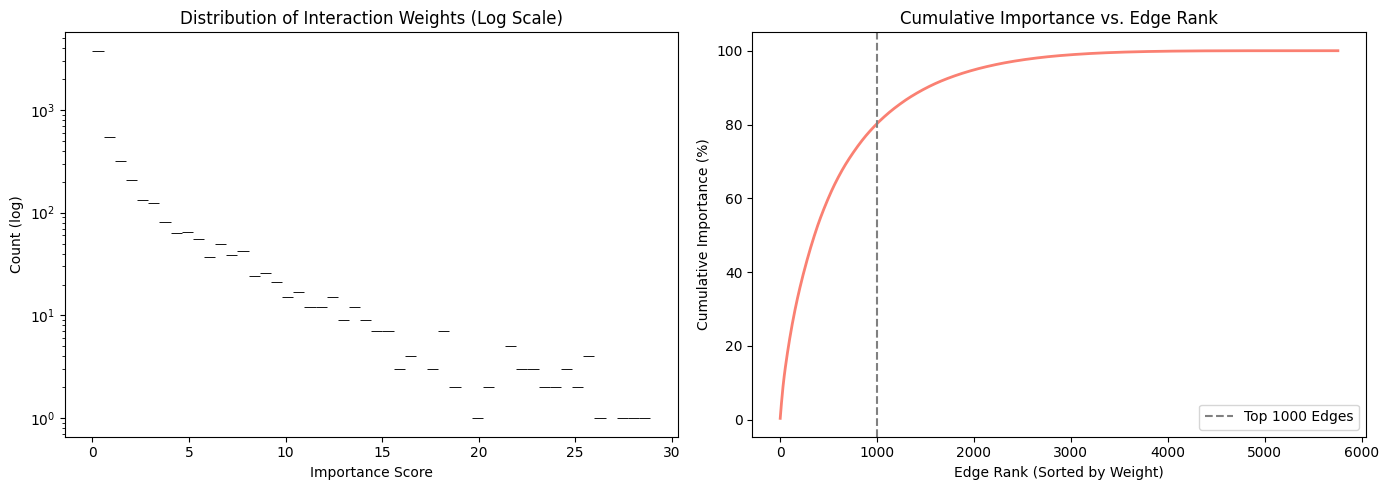

In [7]:
# Sort the edges by importance descending
full_grn = full_grn.sort_values(by="Importance", ascending=False).reset_index(drop=True)
full_grn['Rank'] = full_grn.index + 1

# Calculate cumulative importance percentage
total_importance = full_grn['Importance'].sum()
full_grn['Cumulative_Importance_Pct'] = (full_grn['Importance'].cumsum() / total_importance) * 100

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weight distribution (Log scale on Y)
sns.histplot(data=full_grn, x='Importance', bins=50, ax=axes[0], log_scale=(False, True), color='skyblue')
axes[0].set_title("Distribution of Interaction Weights (Log Scale)")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Count (log)")

# Plot 2: Cumulative weight fall-off depending on rank
axes[1].plot(full_grn['Rank'], full_grn['Cumulative_Importance_Pct'], color='salmon', lw=2)
axes[1].axvline(x=1000, color='gray', linestyle='--', label='Top 1000 Edges')
axes[1].set_title("Cumulative Importance vs. Edge Rank")
axes[1].set_xlabel("Edge Rank (Sorted by Weight)")
axes[1].set_ylabel("Cumulative Importance (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Threshold the network to the top 1,000 edges
thresholded_grn = full_grn.head(1000).copy()
print(f"Filtered network has {len(thresholded_grn)} edges.")

Filtered network has 1000 edges.


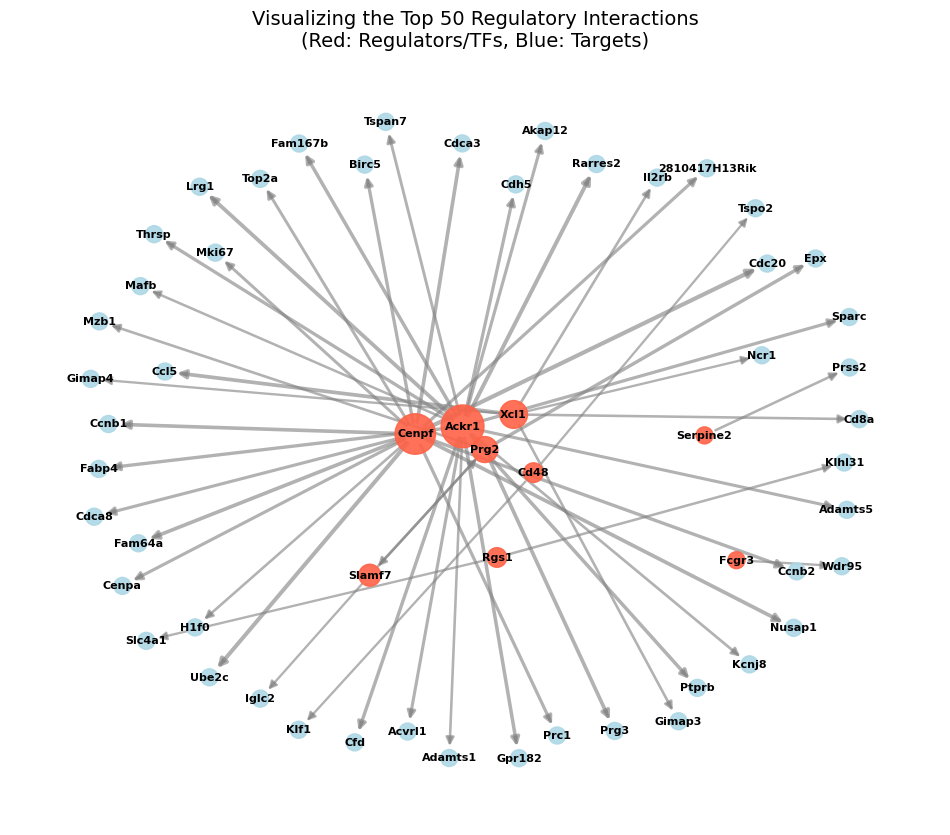

In [9]:
# Filter for the top 50 edges for visualization
viz_df = thresholded_grn.head(50)

# Create a Directed Graph in NetworkX
G = nx.from_pandas_edgelist(
    viz_df, 
    source='TF', 
    target='Target', 
    edge_attr='Importance', 
    create_using=nx.DiGraph()
)

# Identify unique TFs (source nodes) in this sub-network
source_tfs = set(viz_df['TF'])

# Assign node colors: Red for TFs, Blue for Targets (that aren't TFs in this subset)
node_colors = []
for node in G.nodes():
    if node in source_tfs:
        node_colors.append('tomato')
    else:
        node_colors.append('lightblue')

# Scale node sizes based on their total degree (in-degree + out-degree)
node_sizes = [ (G.degree(node) * 50) + 100 for node in G.nodes() ]

# Scale edge widths based on their normalized importance
weights = [G[u][v]['Importance'] for u, v in G.edges()]
max_weight = max(weights)
edge_widths = [ (w / max_weight) * 3 for w in weights ]

# Generate layout
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.4, seed=42)

# Draw graph components
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.6, arrowsize=12)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Visualizing the Top 50 Regulatory Interactions\n(Red: Regulators/TFs, Blue: Targets)", fontsize=14)
plt.axis('off')
plt.show()

In [10]:
# Build a NetworkX graph from our full thresholded network (1000 edges)
G_full = nx.from_pandas_edgelist(
    thresholded_grn, 
    source='TF', 
    target='Target', 
    edge_attr='Importance', 
    create_using=nx.DiGraph()
)

In [11]:
# Calculate degrees
out_degrees = dict(G_full.out_degree())
in_degrees = dict(G_full.in_degree())

# Convert to DataFrame
degree_df = pd.DataFrame({
    'Out_Degree': pd.Series(out_degrees),
    'In_Degree': pd.Series(in_degrees)
}).fillna(0)

# Display top 10 Master Regulators (high out-degree)
print("Top 10 Candidate Master Regulators (by Out-Degree):")
print(degree_df.sort_values(by='Out_Degree', ascending=False).head(10))

Top 10 Candidate Master Regulators (by Out-Degree):
        Out_Degree  In_Degree
Fcer1g         126          4
Cd48            99          3
Rgs1            82          5
Btg2            82          4
Fcgr3           65          4
Rgs2            63          5
Fcer1a          62          3
Slamf7          60          3
Xcl1            52          4
Prg2            52          1


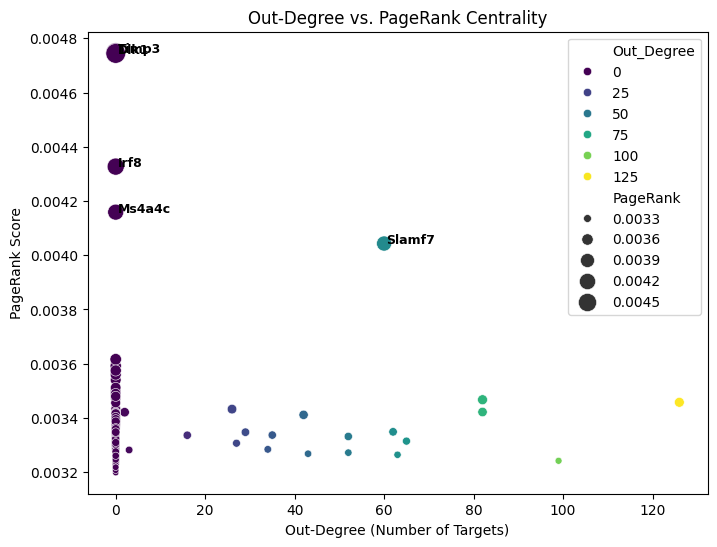

In [12]:
# Calculate weighted PageRank (using 'Importance' as the transition weight)
pagerank_scores = nx.pagerank(G_full, weight='Importance')

# Add to our stats DataFrame
degree_df['PageRank'] = pd.Series(pagerank_scores)

# Scatter plot of Out-Degree vs. PageRank
plt.figure(figsize=(8, 6))
sns.scatterplot(data=degree_df, x='Out_Degree', y='PageRank', hue='Out_Degree', palette='viridis', size='PageRank', sizes=(20, 200))

# Label the top 5 TFs by PageRank
top_tfs = degree_df.sort_values(by='PageRank', ascending=False).head(5)
for gene, row in top_tfs.iterrows():
    plt.text(row['Out_Degree'] + 0.5, row['PageRank'], gene, fontsize=9, weight='bold')

plt.title("Out-Degree vs. PageRank Centrality")
plt.xlabel("Out-Degree (Number of Targets)")
plt.ylabel("PageRank Score")
plt.show()

In [13]:
# Create an inverted 'distance' weight attribute
for u, v, d in G_full.edges(data=True):
    # Avoid division by zero by adding a tiny epsilon
    d['distance'] = 1.0 / (d['Importance'] + 1e-5)

# Calculate betweenness centrality using the inverted distance metric
betweenness = nx.betweenness_centrality(G_full, weight='distance')
degree_df['Betweenness'] = pd.Series(betweenness)

print("\nTop 5 Genes by Betweenness Centrality (Bridges):")
print(degree_df.sort_values(by='Betweenness', ascending=False)['Betweenness'].head(5))


Top 5 Genes by Betweenness Centrality (Bridges):
Xcl1      0.009248
Fcer1g    0.008967
Slamf7    0.008350
Cd48      0.007968
Btg2      0.007149
Name: Betweenness, dtype: float64


In [14]:
import gseapy as gp

In [15]:
# Extract top 30 regulators
top_regulators = degree_df.sort_values(by='Out_Degree', ascending=False).head(30).index.tolist()

print(f"Top 30 Regulators to test: \n{top_regulators}")

Top 30 Regulators to test: 
['Fcer1g', 'Cd48', 'Rgs1', 'Btg2', 'Fcgr3', 'Rgs2', 'Fcer1a', 'Slamf7', 'Xcl1', 'Prg2', 'Cenpf', 'Nr4a2', 'Atf3', 'Ackr1', 'Icos', 'Lcn2', 'Serpine2', 'Khdc1a', 'Ifi205', 'Tnfaip6', 'C3ar1', 'Trdc', 'Areg', 'Igll1', 'Ccr6', 'Cd74', 'Klf4', 'Gzmk', 'Ramp2', 'Hbb-bs']


In [16]:
try:
    # Run the online enrichment analysis
    enr = gp.enrichr(
        gene_list=top_regulators,
        gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
        organism='human',  # Change to 'mouse' if applicable
        outdir=None        # Keep results in memory instead of writing files to disk
    )
    
    # Store results in a pandas DataFrame
    enrichment_df = enr.results
    print("Enrichment run complete!")
    
except Exception as e:
    print(f"Error querying Enrichr API: {e}")
    print("Please check your internet connection and try again.")

Enrichment run complete!


In [17]:
# Filter for significant results
sig_enrichment = enrichment_df[enrichment_df['Adjusted P-value'] < 0.05].copy()

# Sort by significance
sig_enrichment = sig_enrichment.sort_values(by='Adjusted P-value')

print(f"Found {len(sig_enrichment)} significantly enriched pathways.")
# Display the top 10 most significant results
sig_enrichment[['Gene_set', 'Term', 'Adjusted P-value', 'Overlap', 'Genes']].head(10)

Found 12 significantly enriched pathways.


,Gene_set,Term,Adjusted P-value,Overlap,Genes
443,KEGG_2021_Human,Asthma,0.000492,3/31,FCER1G;PRG2;FCER1A
0,GO_Biological_Process_2023,Regulation Of Neutrophil Chemotaxis (GO:0090022),0.002665,3/25,CD74;TNFAIP6;XCL1
1,GO_Biological_Process_2023,Immunoglobulin Mediated Immune Response (GO:00...,0.002665,3/30,CD74;FCER1G;FCER1A
444,KEGG_2021_Human,Primary immunodeficiency,0.027354,2/38,IGLL1;ICOS
4,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),0.029809,4/236,TNFAIP6;C3AR1;XCL1;ACKR1
5,GO_Biological_Process_2023,Positive Regulation Of Granulocyte Chemotaxis ...,0.029809,2/21,CD74;XCL1
2,GO_Biological_Process_2023,B Cell Mediated Immunity (GO:0019724),0.029809,2/15,CD74;FCER1G
3,GO_Biological_Process_2023,Positive Regulation Of Neutrophil Chemotaxis (...,0.029809,2/18,CD74;XCL1
7,GO_Biological_Process_2023,Immune Response-Activating Cell Surface Recept...,0.029809,2/23,FCER1G;C3AR1
6,GO_Biological_Process_2023,Positive Regulation Of Neutrophil Migration (G...,0.029809,2/23,CD74;XCL1


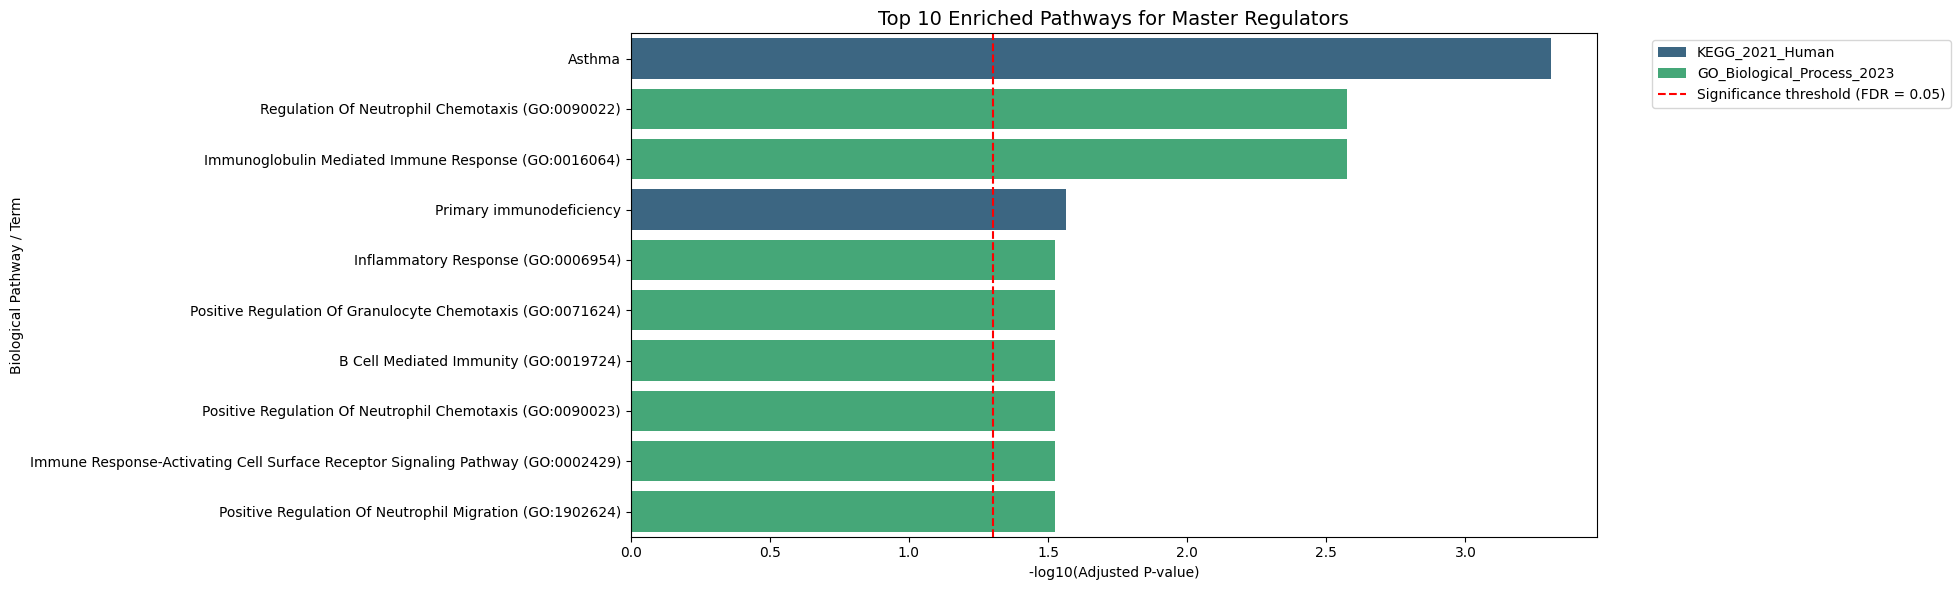

In [19]:
if not sig_enrichment.empty:
    # Select top 10 rows
    plot_data = sig_enrichment.head(10).copy()
    
    # Calculate -log10 Adjusted P-value
    plot_data['-log10_Adj_P'] = -np.log10(plot_data['Adjusted P-value'])
    
    # Draw plot
    plt.figure(figsize=(20, 6))
    sns.barplot(
        data=plot_data,
        x='-log10_Adj_P',
        y='Term',
        hue='Gene_set',
        dodge=False,
        palette='viridis'
    )
    
    plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='Significance threshold (FDR = 0.05)')
    plt.title("Top 10 Enriched Pathways for Master Regulators", fontsize=14)
    plt.xlabel("-log10(Adjusted P-value)")
    plt.ylabel("Biological Pathway / Term")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No terms were significantly enriched below FDR 0.05.")
    print("Try increasing your candidate master regulator list (e.g., top 50 or 100 TFs).")